fosA_3_ACWO01000079 coverage: 100.0 depth: 1982.9 min_depth: 490
catB4_1_EU935739 coverage: 100.0 depth: 1648.83 min_depth: 596
blaSHV-28_1_HM751101 coverage: 100.0 depth: 1165.98 min_depth: 729
tet(A)_4_AJ517790 coverage: 100.0 depth: 944.75 min_depth: 591
aac(6')Ib-cr_1_DQ303918 coverage: 100.0 depth: 831.63 min_depth: 607
aac(3)-IIa_1_CP023555.1 coverage: 100.0 depth: 799.83 min_depth: 393
strB_1_M96392 coverage: 100.0 depth: 787.78 min_depth: 549
blaOXA-1_1_J02967 coverage: 100.0 depth: 753.12 min_depth: 555
blaTEM-1B_1_JF910132 coverage: 100.0 depth: 752.94 min_depth: 556
blaCTX-M-15_23_DQ302097 coverage: 100.0 depth: 741.78 min_depth: 436
strA_4_AF321551 coverage: 100.0 depth: 734.07 min_depth: 549
sul2_2_GQ421466 coverage: 100.0 depth: 632.37 min_depth: 323
dfrA14_1_DQ388123 coverage: 99.55 depth: 717.02 min_depth: 0
oqxA_1_EU370913 coverage: 98.6 depth: 1571.86 min_depth: 0
oqxB_1_EU370913 coverage: 96.6 depth: 1445.25 min_depth: 0


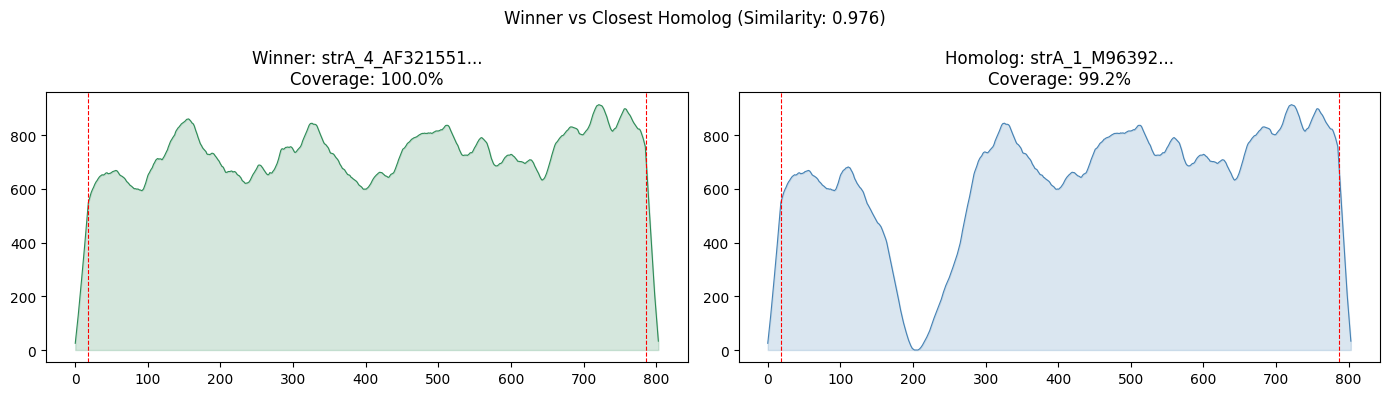

TARGET GENE FROM LIST vs CLOSEST DATABASE HOMOLOG
....................................................................................................

--- Analysis for: aac(6')Ib-cr_1_DQ303918
Total Gene Length: 600 bp
Core Region (excluding edges): 564 bp
Positions with at least 1 read: 564
Coverage = (564 / 564) * 100 = 100.00%
Total depth sum in core: 469042
Average Depth = 469042 / 564 = 831.63x
Number of Gaps: 0

> Closest Homolog: aac(6')Ib-cr_2_EF636461
> Similarity Score: 0.9621

--- Analysis for: aac(6')Ib-cr_2_EF636461
Total Gene Length: 519 bp
Core Region (excluding edges): 483 bp
Positions with at least 1 read: 477
Coverage = (477 / 483) * 100 = 98.76%
Total depth sum in core: 276890
Average Depth = 276890 / 483 = 573.27x
Number of Gaps: 6

....................................................................................................

--- Analysis for: strA_4_AF321551
Total Gene Length: 804 bp
Core Region (excluding edges): 768 bp
Positions with at least 1 read: 768


In [ ]:
import gzip
import random
import matplotlib.pyplot as plt

##### FASTA #####
class Fasta:
    def __init__(self, filename):
        self.filename = filename
        self.gene_length = {}
        self.gene_sequences = {}

    def reading_dnaFasta(self):
        '''
        Reads a FASTA file and yields header and sequence
        '''
        infile = open(self.filename, 'r')
        header = ''
        sequence = ''

        for line in infile:
            line = line.strip()
            if line.startswith('>'):
                if header != '':
                    yield header, sequence
                header = line[1:]
                sequence = ''
            else:
                sequence += line
        if sequence != '':
            yield header, sequence

        infile.close()

    def read_fasta_dict(self):
        '''
        Returns gene_length and gene_sequences with the key being the gene
        '''
        for header, seq in self.reading_dnaFasta():
            name = header.strip().split(' ')[0]
            self.gene_length[name] = len(seq)
            self.gene_sequences[name] = seq


##### DNA #####
class DNA:
    def reverse_com_strand(self, sequence):
        '''
        Returns the reverse complement of the input sequence
        '''
        comp = {'A':'T','T':'A','G':'C','C':'G'}
        rev = []
        for base in sequence[::-1]:
            if base in comp:
                rev.append(comp[base])
            else:
                rev.append('N')
        return ''.join(rev)

    def nineteen_pos(self, DNA_seq):
        '''
        Takes out a DNA sequence and returns a kmer and its position in the sequence
        '''
        for i in range(len(DNA_seq) - 18):
            kmer = DNA_seq[i:i+19]
            if 'N' not in kmer:
                yield i, kmer


##### KMER #####
class Kmer:
    def __init__(self, fasta):
        self.fasta = fasta
        self.kmer_index = {}
        self.dna = DNA()

    def create_dict_kmer(self):
        '''
        Computes the kmers for all gene sequences, both forward and reverse.
        Each k-mer maps to a list of (gene_name, position, strand) entries
        '''
        for header, sequence in self.fasta.reading_dnaFasta():
            gene_name = header.strip().split(' ')[0]

            for position, kmer in self.dna.nineteen_pos(sequence):
                if kmer not in self.kmer_index:
                    self.kmer_index[kmer] = []
                self.kmer_index[kmer].append((gene_name, position, '+'))
            
            rev = self.dna.reverse_com_strand(sequence)
            for rev_position, kmer in self.dna.nineteen_pos(rev):
                if kmer not in self.kmer_index:
                    self.kmer_index[kmer] = []
                self.kmer_index[kmer].append((gene_name, rev_position, '-'))


##### FASTQ #####
class Fastq:
    def __init__(self, filename):
        self.filename = filename

    def fastqread(self):
        '''
        Inputs the fastq file and yields the sequence of each read in the file
        '''
        infile = gzip.open(self.filename, 'rt')

        while True:
            header = infile.readline()
            if not header:
                break
            seq = infile.readline().rstrip()
            infile.readline()
            infile.readline()

            if len(seq) == 0:
                break

            yield seq

        infile.close()


##### MATCHING #####
class Match:
    def __init__(self, fastq_files, resistance_kmer, gene_lengths):
        self.fastq_files = fastq_files
        self.resistance_kmer = resistance_kmer
        self.gene_lengths = gene_lengths

        self.dict_depth = {gene: [0] * length for gene, length in gene_lengths.items()}
        self.unique_match_counts = {gene: 0 for gene in gene_lengths}

    def match_reads_to_genes(self):
        '''
        Map sequencing reads to reference genes using k-mer matches
        '''
        for fastq_file in self.fastq_files:
            fastq = Fastq(fastq_file)

            for read in fastq.fastqread():
                read_len = len(read)

                if read_len < 19:
                    continue

                possible_hit = False
                for pos in range(0, read_len - 18, 20):
                    kmer = read[pos:pos + 19]
                    if 'N' in kmer:
                        continue
                    if kmer in self.resistance_kmer:
                        possible_hit = True
                        break
                if not possible_hit:
                    continue

                reads_found_gene = {}

                for read_pos in range(read_len - 18):
                    kmer_read = read[read_pos:read_pos + 19]
                    if 'N' in kmer_read or kmer_read not in self.resistance_kmer:
                        continue

                    genes_matched = self.resistance_kmer[kmer_read]
                    first_gene_matched = genes_matched[0][0]
                    unique = True
                    for entry in genes_matched:
                        if entry[0] != first_gene_matched:
                            unique = False
                            break

                    for gene, gene_pos, strand in genes_matched:
                        alignment_shift = gene_pos - read_pos
                        id = (gene, alignment_shift, strand)

                        if id not in reads_found_gene:
                            reads_found_gene[id] = [0, 0]

                        reads_found_gene[id][0] += 1
                        if unique:
                            reads_found_gene[id][1] += 1

                if not reads_found_gene:
                    continue

                best_hits = 0
                for info in reads_found_gene.values():
                    if info[0] > best_hits:
                        best_hits = info[0]

                if best_hits < 3:
                    continue

                for read_pos in range(read_len - 18):
                    kmer_read = read[read_pos:read_pos + 19]
                    if 'N' in kmer_read:
                        continue

                    genes_matched = self.resistance_kmer.get(kmer_read)
                    if genes_matched is None:
                        continue

                    for gene, gene_pos, strand in genes_matched:
                        alignment_shift = gene_pos - read_pos
                        id = (gene, alignment_shift, strand)

                        if id in reads_found_gene and reads_found_gene[id][0] == best_hits:
                            gene_len = self.gene_lengths[gene]
                            if strand == '+':
                                start = alignment_shift + read_pos
                            else:
                                start = gene_len - 19 - (alignment_shift + read_pos)

                            if 0 <= start <= gene_len - 19:
                                for p in range(start, start + 19):
                                    self.dict_depth[gene][p] += 1

                for (gene, shift, strand), (total_hits, unique_hits) in reads_found_gene.items():
                    if total_hits == best_hits:
                        self.unique_match_counts[gene] += unique_hits


##### ANALYSIS CLASS #####
class Analysis:
    def __init__(self, dict_depth, gene_length, resistance_kmer, dict_unique_hits):
        self.dict_depth = dict_depth
        self.gene_length = gene_length
        self.resistance_kmer = resistance_kmer
        self.dict_unique_hits = dict_unique_hits

    def calculate_coverage_depth(self, min_cov=95, min_depth=10):
        '''
        Filter genes by minimum core coverage and average core depth.
        '''
        filtered_genes = {}

        for gene, pos_counts in self.dict_depth.items():
            gene_len = self.gene_length[gene]
            
            core_start = 18
            core_end = gene_len - 18

            if core_end <= core_start: 
                continue

            core = pos_counts[core_start:core_end]
            n = len(core)

            covered = sum(1 for pos_depth in core if pos_depth > 0)
            coverage = covered / n * 100
            avg_depth = sum(core) / n

            if coverage >= min_cov and avg_depth >= min_depth:
                filtered_genes[gene] = {
                    'coverage': coverage,
                    'depth': avg_depth,
                    'min_depth': min(core) if core else 0
                }

        return filtered_genes


    def join_genes_by_similarity(self, filtered_genes, threshold=0.5):
        '''
        Collapse near-identical alleles
        '''

        gene_kmers = {gene: set() for gene in self.gene_length}
        for kmer, entries in self.resistance_kmer.items():
            for gene, position, strand in entries:
                gene_kmers[gene].add(kmer)

        gene_list = list(filtered_genes.keys())
        removed = set()

        for i in range(len(gene_list)):
            for j in range(i + 1, len(gene_list)):
                gene_a = gene_list[i]
                gene_b = gene_list[j]

                if gene_a in removed or gene_b in removed:
                    continue

                kmer_a = gene_kmers[gene_a]
                kmer_b = gene_kmers[gene_b]

                shared = len(kmer_a.intersection(kmer_b))

                if shared == 0:
                    continue

                smaller = kmer_a if len(kmer_a) < len(kmer_b) else kmer_b

                similarity = shared / len(smaller)

                if similarity >= threshold:
                    stat_a = filtered_genes[gene_a]
                    stat_b = filtered_genes[gene_b]

                    if stat_a['coverage'] != stat_b['coverage']:
                        better, worse = (gene_a, gene_b) if stat_a['coverage'] > stat_b['coverage'] else (gene_b, gene_a)
                    elif stat_a['depth'] != stat_b['depth']:
                        better, worse = (gene_a, gene_b) if stat_a['depth'] > stat_b['depth'] else (gene_b, gene_a)
                    else:
                        better, worse = (gene_a, gene_b) if self.dict_unique_hits[gene_a] >= self.dict_unique_hits[gene_b] else (gene_b, gene_a)

                    removed.add(worse)

        final = {}
        for gene in filtered_genes:
            if gene not in removed:
                final[gene] = filtered_genes[gene]


        return final, removed



    # --- EXTRAS ADDED TO ANALYSIS CLASS ---

    def find_closest_homolog(self, target_gene):
        '''
        Find the most similar gene in the database to target_gene
        '''
        target_kmers = set()
        other_gene_kmers = {}

        for kmer, entries in self.resistance_kmer.items():
            for entry in entries:
                gene = entry[0]
                if gene == target_gene:
                    target_kmers.add(kmer)
                else:
                    if gene not in other_gene_kmers:
                        other_gene_kmers[gene] = set()
                    other_gene_kmers[gene].add(kmer)

        if not target_kmers: return None, 0.0

        best_gene, best_similarity = None, 0.0

        for gene, kmers in other_gene_kmers.items():
            shared = len(target_kmers.intersection(kmers))
            if shared == 0: continue

            min_size = min(len(target_kmers), len(kmers))
            similarity = shared / min_size

            if similarity > best_similarity:
                best_similarity, best_gene = similarity, gene

        return best_gene, best_similarity


    def stats(self, depth_list, k_value=19):
        '''
        Calculates metrics for a specific gene depth list
        '''
        core = depth_list[k_value - 1 : -(k_value - 1)]
        n = len(core)
        if n <= 0: return None

        covered = sum(1 for d in core if d > 0)
        depth_sum = sum(core)

        return {
            'total_length': len(depth_list),
            'core_length': n,
            'covered_bases': covered,
            'depth_sum': depth_sum,
            'coverage_pct': (covered / n) * 100,
            'average_depth': depth_sum / n,
            'minimum_depth': min(core) if core else 0,
            'zero_positions': n - covered
        }


    def print_gene_explanation(self, gene_name, k_value=19):
        '''
        Prints the math behinf the statistics to compare genes later
        '''
        if gene_name not in self.dict_depth:
            print(f"Could not find gene: {gene_name}")
            return

        result = self.stats(self.dict_depth[gene_name], k_value)
        if not result: return

        print(f"\n--- Analysis for: {gene_name}")
        print(f"Total Gene Length: {result['total_length']} bp")
        print(f"Core Region (excluding edges): {result['core_length']} bp")
        print(f"Positions with at least 1 read: {result['covered_bases']}")
        print(f"Coverage = ({result['covered_bases']} / {result['core_length']}) * 100 = {result['coverage_pct']:.2f}%")
        print(f"Total depth sum in core: {result['depth_sum']}")
        print(f"Average Depth = {result['depth_sum']} / {result['core_length']} = {result['average_depth']:.2f}x")
        print(f"Number of Gaps: {result['zero_positions']}")


    def plot_winner_vs_homolog(self, final_results, similarity_threshold=0.5):
        '''
        Visual plots of a winner and its closest homolog for comparison of profiles
        '''
        k_size = 19
        gene_kmer_map = {gene: set() for gene in self.gene_length}

        for kmer, entries in self.resistance_kmer.items():
            for entry in entries:
                gene_kmer_map[entry[0]].add(kmer)

        winner_list = list(final_results.keys())
        random.shuffle(winner_list)

        best_winner, best_homolog, best_sim = None, None, 0.0

        for winner in winner_list:
            winner_kmers = gene_kmer_map[winner]
            local_best_sim, local_best_gene = 0.0, None

            for gene, kmers in gene_kmer_map.items():
                if gene == winner: continue

                shared = len(winner_kmers.intersection(kmers))
                if shared == 0: continue

                sim = shared / min(len(winner_kmers), len(kmers))

                if sim > local_best_sim:
                    local_best_sim, local_best_gene = sim, gene

            if local_best_sim >= similarity_threshold:
                best_winner, best_homolog, best_sim = winner, local_best_gene, local_best_sim
                break

        if not best_winner:
            print("No pairs found for plotting"); return

        winner_stats = self.stats(self.dict_depth[best_winner], k_size)
        homolog_stats = self.stats(self.dict_depth[best_homolog], k_size)

        fig, (ax_w, ax_h) = plt.subplots(1, 2, figsize=(14, 4))

        for ax, gene, stats, color, label in zip(
            [ax_w, ax_h],
            [best_winner, best_homolog],
            [winner_stats, homolog_stats],
            ['seagreen', 'steelblue'],
            ['Winner', 'Homolog']
        ):
            depth = self.dict_depth[gene]
            ax.plot(depth, color=color, linewidth=0.8)
            ax.fill_between(range(len(depth)), depth, color=color, alpha=0.2)
            ax.axvline(x=k_size-1, color='red', linestyle='--', linewidth=0.8)
            ax.axvline(x=len(depth)-(k_size-1), color='red', linestyle='--', linewidth=0.8)
            ax.set_title(f"{label}: {gene[:25]}...\nCoverage: {stats['coverage_pct']:.1f}%")

        plt.suptitle(f"Winner vs Closest Homolog (Similarity: {best_sim:.3f})")
        plt.tight_layout(); plt.show()
# ----------------------------
# MAIN EXECUTION 
# ----------------------------
if __name__ == '__main__':
    fasta_file = 'resistance_genes.fsa.txt'
    fastq_files = ['Unknown3_raw_reads_1.txt.gz', 'Unknown3_raw_reads_2.txt.gz']

    # Load Data
    fasta = Fasta(fasta_file)
    fasta.read_fasta_dict()

    # Index Kmers
    kmer = Kmer(fasta)
    kmer.create_dict_kmer()

    # Match Reads
    matcher = Match(fastq_files, kmer.kmer_index, fasta.gene_length)
    matcher.match_reads_to_genes()

    # Initialize Analysis
    analysis = Analysis(matcher.dict_depth, fasta.gene_length, 
                        kmer.kmer_index, matcher.unique_match_counts)

    # Filtering and Collapsing
    filtered_genes = analysis.calculate_coverage_depth()
    final_genes, removed = analysis.join_genes_by_similarity(filtered_genes)

    sorted_genes = sorted(final_genes.items(),
        key=lambda x: (-x[1]['coverage'], -x[1]['depth'], -x[1]['min_depth']))

    for gene, stats in sorted_genes:
        print(gene, "coverage:", round(stats['coverage'], 2),
              "depth:", round(stats['depth'], 2),
              "min_depth:", round(stats['min_depth'], 2))

    # EXTRAS: Plotting and Detailed Report
    analysis.plot_winner_vs_homolog(final_genes)

    target_genes_list = [
    "aac(6')Ib-cr_1_DQ303918",
    "strA_4_AF321551",
    "strB_1_M96392",
    "aac(3)-IIa_1_CP023555.1",
    "blaCTX-M-15_23_DQ302097",
    "blaOXA-1_1_J02967",
    "blaSHV-28_1_HM751101",
    "blaTEM-1B_1_JF910132",
    "fosA_3_ACWO01000079",
    "catB4_1_EU935739",
    "oqxA_1_EU370913",
    "oqxB_1_EU370913",
    "sul2_2_GQ421466",
    "tet(A)_4_AJ517790",
    "dfrA14_1_DQ388123"
]
    
    print("TARGET GENE FROM LIST vs CLOSEST DATABASE HOMOLOG")
    print("." * 100)

    for current_gene in target_genes_list:
        analysis.print_gene_explanation(current_gene)
        
        closest_name, similarity_value = analysis.find_closest_homolog(current_gene)
        if closest_name:
            print(f"\n> Closest Homolog: {closest_name}")
            print(f"> Similarity Score: {similarity_value:.4f}")
            analysis.print_gene_explanation(closest_name)
        else:
            print("\n> No similar genes found")

        print("\n" + "." * 100)